In [ ]:
!pip install qiskit qiskit-aer matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 3.8 MB/s eta 0:00:00


In [ ]:
!pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=edc7db2cb3f76a55abcbb14e45a894330161877fdf243b057fb301c9cf10dd3e
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

### **Problem 1 - Bell States**

# **$X$ Gate (Pauli-X)**
The **Bit-Flip** gate. It acts as the quantum version of a classical NOT gate, swapping the $|0\rangle$ and $|1\rangle$ states.
$$X|0\rangle = |1\rangle \quad \text{and} \quad X|1\rangle = |0\rangle$$
In matrix form:
$$X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$$

# **$H$ Gate (Hadamard)**
The **Superposition** gate. It creates a 50/50 probability of measuring either basis state. It also maps the computational basis to the sign basis ($|+\rangle$ and $|-\rangle$).
$$H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}} \quad \text{and} \quad H|1\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}$$
In matrix form:
$$H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

# **$\text{CNOT}$ Gate (Controlled-NOT)**
The **Entangling** gate. It acts on a two-qubit system: if the control qubit $|c\rangle$ is $|1\rangle$, it applies an $X$ gate to the target qubit $|t\rangle$.
$$\text{CNOT} |c, t\rangle = |c, c \oplus t\rangle$$
This results in the following transformations:
$$\begin{aligned}
|00\rangle &\to |00\rangle \\
|01\rangle &\to |01\rangle \\
|10\rangle &\to |11\rangle \\
|11\rangle &\to |10\rangle
\end{aligned}$$


> def pretty_formula(state):

Formats the quantum statevector into a symbolic expression using ±1/√2 coefficients.

In [ ]:
def pretty_formula(state):
    """
    Formats the quantum statevector into a symbolic expression using ±1/√2,
    with correct placement of + or - between terms.
    """
    vec = state.data
    n = state.num_qubits

    print("\nState (symbolic):")
    terms = []

    for i, amp in enumerate(vec):
        if abs(amp) > 1e-9:
            basis = format(i, f"0{n}b")
            if amp.real > 0:
                terms.append(f"+ (1/√2)|{basis}>")
            else:
                terms.append(f"- (1/√2)|{basis}>")


    expression = " ".join(terms)
    if expression.startswith("+ "):
        expression = expression[2:]

    print(expression)


### 1. The First Bell State: $|\Phi^+\rangle$= $\frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$
1.  $|00\rangle$
2.  **Apply H to Qubit 1:** $\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) \otimes |0\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |10\rangle)$
3.  **Apply CNOT (Control: Q1, Target: Q2):** $\frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$

**=>** $CNOT \cdot (H \otimes I) |00\rangle$

In [ ]:
# Start with |00>
qc = QuantumCircuit(2)

#  Use the gates
qc.h(0)           # Apply Hadamard to Qubit 0
qc.cx(0, 1)       # Apply CNOT (Control: 0, Target: 1)

# Print the statevector
print("State: Phi+")
state = Statevector.from_instruction(qc)
print(state)

# Pretty symbolic form
pretty_formula(state)

#  Draw the circuit
print(qc.draw('text'))


State: Phi+
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))

State (symbolic):
(1/√2)|00> + (1/√2)|11>
     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘


*   0.707 is $1/\sqrt{2}$.
*   The first number is the amplitude for $|00\rangle$.
*   The last number is the amplitude for $|11\rangle$.
*   Since the middle two are 0, it confirms the qubits are perfectly entangled.

### 2. The Second Bell State: $|\Phi^-\rangle$= $\frac{1}{\sqrt{2}}(|00\rangle - |11\rangle)$
1.  $|00\rangle$
2.  **Apply X to Qubit 1:** $|10\rangle$ (This prepares the "minus" phase via the Hadamard gate)
3.  **Apply H to Qubit 1:** $\frac{1}{\sqrt{2}}(|0\rangle - |1\rangle) \otimes |0\rangle = \frac{1}{\sqrt{2}}(|00\rangle - |10\rangle)$
4.  **Apply CNOT** (Control: Q1, Target: Q2): $\frac{1}{\sqrt{2}}(|00\rangle - |11\rangle)$

**=>** $CNOT \cdot (H \otimes I) \cdot (X \otimes I) |00\rangle$

In [ ]:
#  Start with |00>
qc = QuantumCircuit(2)

#  Apply gates
qc.x(0)        # X on qubit 0 → |10>
qc.h(0)        # H on qubit 0
qc.cx(0, 1)    # CNOT

# Display result
print("State produced:")
state = Statevector.from_instruction(qc)
print(state)

# Pretty symbolic form
pretty_formula(state)

# Draw circuit
print(qc.draw('text'))


State produced:
Statevector([ 0.70710678+0.j,  0.        +0.j,  0.        +0.j,
             -0.70710678+0.j],
            dims=(2, 2))

State (symbolic):
(1/√2)|00> - (1/√2)|11>
     ┌───┐┌───┐     
q_0: ┤ X ├┤ H ├──■──
     └───┘└───┘┌─┴─┐
q_1: ──────────┤ X ├
               └───┘


### 3. The Third Bell State: $|\Psi^+\rangle$= $\frac{1}{\sqrt{2}}(|01\rangle + |10\rangle)$
1.   $|00\rangle$
2.  **Apply X to Qubit 2:** $|01\rangle$
3.  **Apply H to Qubit 1:** $\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) \otimes |1\rangle = \frac{1}{\sqrt{2}}(|01\rangle + |11\rangle)$
4.  **Apply CNOT** (Control: Q1, Target: Q2): $\frac{1}{\sqrt{2}}(|01\rangle + |10\rangle)$

**=>** $CNOT \cdot (H \otimes I) \cdot (I \otimes X) |00\rangle$



In [ ]:
#  Start with |00>
qc = QuantumCircuit(2)

#  Apply gates
qc.x(1)        # X on qubit 1 → |01>
qc.h(0)        # H on qubit 0
qc.cx(0, 1)    # CNOT

# Display result
print("State produced:")
state = Statevector.from_instruction(qc)
print(state)
# Pretty symbolic form
pretty_formula(state)

# Draw circuit (text mode, no pylatexenc needed)
print(qc.draw('text'))


State produced:
Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))

State (symbolic):
(1/√2)|01> + (1/√2)|10>
     ┌───┐     
q_0: ┤ H ├──■──
     ├───┤┌─┴─┐
q_1: ┤ X ├┤ X ├
     └───┘└───┘


### 4. The Fourth Bell State: $|\Psi^-\rangle$= $\frac{1}{\sqrt{2}}(|01\rangle - |10\rangle)$
1.   $|00\rangle$
2.  **Apply X to Qubit 1 and Qubit 2:** $|11\rangle$
3.  **Apply H to Qubit 1:** $ \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle) \otimes |1\rangle = \frac{1}{\sqrt{2}}(|10\rangle - |11\rangle)$
4.  **Apply CNOT** (Control: Q1, Target: Q2): $\frac{1}{\sqrt{2}}(|01\rangle - |10\rangle)$

**=>** $CNOT \cdot (H \otimes I) \cdot (X \otimes X) |00\rangle$

In [ ]:
#  Start with |00>
qc = QuantumCircuit(2)

#  Apply gates
qc.x(0)        # X on qubit 0 → |10>
qc.x(1)        # X on qubit 1 → |11>
qc.h(1)        # H on qubit 1
qc.cx(1, 0)    # CNOT

# Display result
print("State: Psi-")
state = Statevector.from_instruction(qc)
print(state)
# Pretty symbolic form
pretty_formula(state)

# Draw circuit (text mode — no pylatexenc needed)
print(qc.draw('text'))


State: Psi-
Statevector([ 0.        +0.j,  0.70710678+0.j, -0.70710678+0.j,
              0.        +0.j],
            dims=(2, 2))

State (symbolic):
(1/√2)|01> - (1/√2)|10>
     ┌───┐     ┌───┐
q_0: ┤ X ├─────┤ X ├
     ├───┤┌───┐└─┬─┘
q_1: ┤ X ├┤ H ├──■──
     └───┘└───┘     


## **Problem 2 - Quantum Teleportation**

Quantum teleportation is a protocol that allows us to move a quantum state (the information) from one location to another without actually moving the physical particle itself.

To teleport a state, we need three main components:
1.  **Shared Entanglement:** Alice and Bob must first share a pair of entangled qubits (a "Bell Pair"). This is a "quantum link" connecting them.
2.  **Alice’s Interaction:** Alice takes the qubit she wants to send (the "Message Qubit") and interacts it with her half of the entangled pair. This "tangles" the message into the quantum link.
3.  **Measurement:** Alice measures her two qubits. This process is destructive: the original quantum state is destroyed (satisfying the *No-Cloning Theorem*).
4.  **Classical Communication:** Alice's measurement results in two ordinary classical bits (0 or 1). She sends these to Bob via a normal method, like a phone call or the internet.
5.  **Bob’s Reconstruction:** Based on Alice's two bits, Bob knows exactly how to rotate his half of the entangled pair to turn it into the original message state.

*   **No-Cloning Theorem:** In quantum mechanics, you cannot make an exact copy of an unknown state. Teleportation gets around this by moving the state rather than copying it (the original is destroyed).
*   **Speed Limit:** Even though entanglement is "instant," the teleportation is not faster than light. Bob cannot reconstruct the state until he receives Alice’s classical bits, which travel at the speed of light.
*   **Quantum Internet:** This protocol is the foundation for future quantum networks, allowing quantum computers to share data securely over long distances.

To implement the quantum teleportation protocol, we use three qubits:
1.  **Qubit 0 (Alice):** The state to be teleported (the $|+\rangle$ state).
2.  **Qubit 1 (Alice):** Alice’s half of the entangled Bell pair.
3.  **Qubit 2 (Bob):** Bob’s half of the entangled Bell pair (where the state will appear).


### Explanation of the Steps

1.   I apply a Hadamard ($H$) gate to Alice's qubit ($q_0$). This puts it into the state $|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$.
2.  **Creating Entanglement:** Alice and Bob share a Bell pair ($q_1$ and $q_2$). I create this using an $H$ gate followed by a $CNOT$. Bob takes his qubit ($q_2$) and moves away.
3.  **Alice’s Interaction:** Alice performs a $CNOT$ between her input qubit ($q_0$) and her Bell-pair qubit ($q_1$). She then applies an $H$ gate to $q_0$. This entangles the input state with the Bell pair.
4.  **Measurement:** Alice measures both her qubits. This collapses the system. Because of the entanglement, Bob’s qubit ($q_2$) is now in one of four versions of Alice's original state, depending on her measurement outcome.
5.  **Bob’s Correction:** Alice sends her two classical bits to Bob.
    *   If Alice's second bit is 1, Bob applies an **X (NOT)** gate.
    *   If Alice's first bit is 1, Bob applies a **Z (Phase Flip)** gate.
    *   In our specific case (teleporting $|+\rangle$), the Z gate correction is crucial because the $|+\rangle$ state is sensitive to phase flips ($Z|+\rangle = |-\rangle$).


### How to Verify the Result

If the protocol worked, Bob's qubit ($q_2$) should now be in the $|+\rangle$ state. In Qiskit's statevector output:
*   The $|+\rangle$ state is represented by $\begin{pmatrix} \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \end{pmatrix} \approx \begin{pmatrix} 0.707 \\ 0.707 \end{pmatrix}$.
*   When we run the code, we will see that the probability amplitudes for Bob's qubit match the $|+\rangle$ state regardless of Alice's measurement outcomes.

 If we were to measure Bob's qubit in the standard basis ($|0\rangle, |1\rangle$), we would get a 50/50 split. To "prove" it is $|+\rangle$ via measurement, we would apply an $H$ gate to Bob's qubit before measuring; if the teleportation was successful, Bob would measure $|0\rangle$ with 100% probability.

In [ ]:
!pip install qiskit-aer

In [ ]:
!pip install qiskit qiskit-aer matplotlib pylatexenc

In [ ]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt

In [ ]:
def run_teleportation():
    """
    Initializes and runs the quantum teleportation protocol for the |+> state.
    """
    # Setup the Circuit
    qr = QuantumRegister(3, name="q")
    crz = ClassicalRegister(1, name="crz") # Alice's result for q0
    crx = ClassicalRegister(1, name="crx") # Alice's result for q1
    circuit = QuantumCircuit(qr, crz, crx)

    # ---  Prepare the input state |+> on q0 ---
    # Target state: |+> = 1/√2(|0> + |1>)
    circuit.h(0)
    circuit.barrier()

    # ---  Create the Bell pair between q1 and q2 ---
    circuit.h(1)
    circuit.cx(1, 2)
    circuit.barrier()

    # ---  Alice's protocol ---
    circuit.cx(0, 1)
    circuit.h(0)
    circuit.barrier()

    # ---  Alice's Measurement ---
    circuit.measure(0, crz)
    circuit.measure(1, crx)
    circuit.barrier()

    # ---  Bob's corrections (MODERN SYNTAX) ---
    with circuit.if_test((crx, 1)):
        circuit.x(2)
    with circuit.if_test((crz, 1)):
        circuit.z(2)

    # --- VERIFICATION ---
    backend = AerSimulator()
    # Save the statevector to verify Bob's qubit
    circuit.save_statevector()

    # Run the simulation
    job = backend.run(circuit)
    result = job.result()
    out_state = result.get_statevector()

    # Print Numerical Amplitudes
    print("Teleportation Successful.")
    print("\nNumerical Statevector (Raw):")
    print(out_state.data[np.abs(out_state.data) > 0.1]) # Filter out zeros

    #  Print using your custom Pretty Formula
    pretty_formula(out_state)

    # Explain the formula output
    print("Note: In the basis |b2 b1 b0>, b0 and b1 are Alice's fixed measurement results,")
    print("and b2 is Bob's qubit. Since Bob has |+>, we should see both |0 b1 b0> and |1 b1 b0>")
    print("appearing with the same sign and 1/√2 amplitude.")

    #  Visual Verification
    # Qubit 2 (Bob's) should be pointing to +X on the Bloch sphere
    display(plot_bloch_multivector(out_state))

Teleportation Successful.

Numerical Statevector (Raw):
[0.70710678+0.00000000e+00j 0.70710678-8.65956056e-17j]

State (symbolic):
(1/√2)|000> + (1/√2)|100>
Note: In the basis |b2 b1 b0>, b0 and b1 are Alice's fixed measurement results,
and b2 is Bob's qubit. Since Bob has |+>, we should see both |0 b1 b0> and |1 b1 b0>
appearing with the same sign and 1/√2 amplitude.


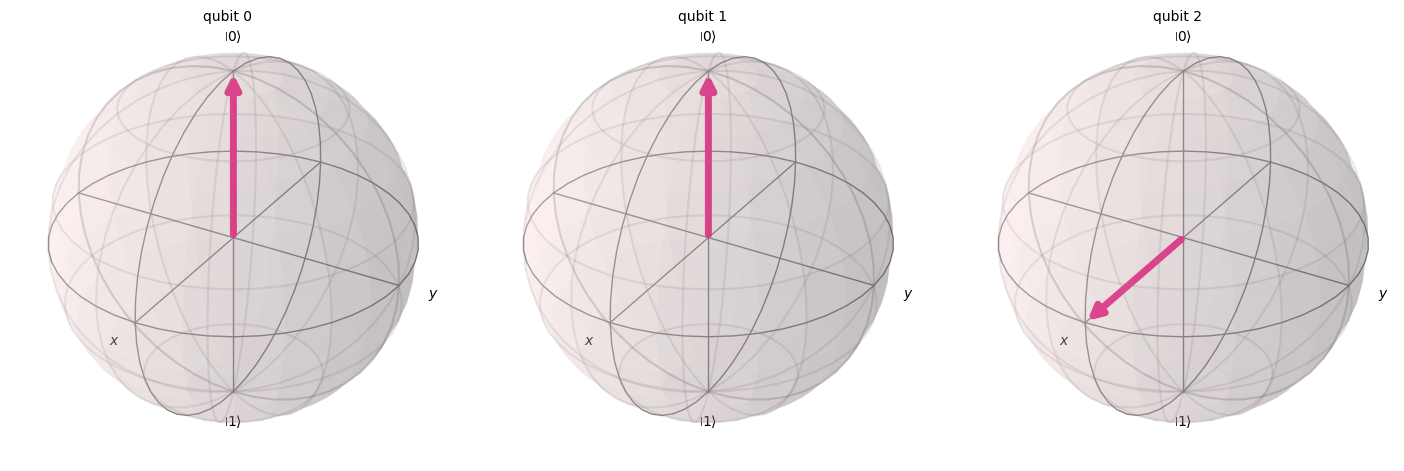

In [ ]:
run_teleportation()

Teleportation Successful.

Numerical Statevector (Raw):
[0.70710678+0.00000000e+00j 0.70710678-8.65956056e-17j]

State (symbolic):
(1/√2)|011> + (1/√2)|111>
Note: In the basis |b2 b1 b0>, b0 and b1 are Alice's fixed measurement results,
and b2 is Bob's qubit. Since Bob has |+>, we should see both |0 b1 b0> and |1 b1 b0>
appearing with the same sign and 1/√2 amplitude.


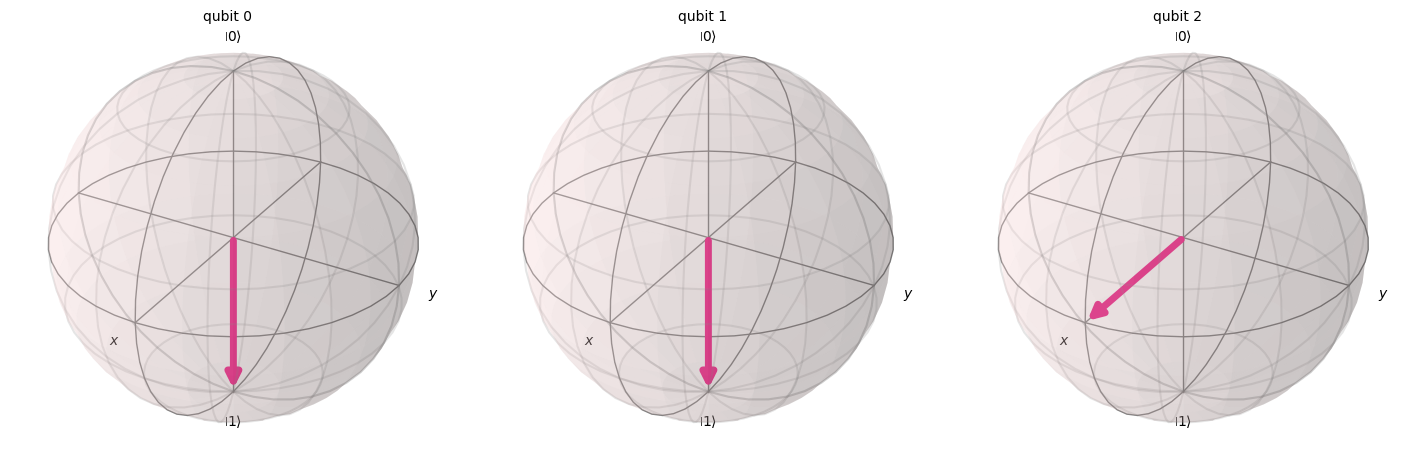

In [ ]:
run_teleportation()

Teleportation Successful.

Numerical Statevector (Raw):
[0.70710678+0.00000000e+00j 0.70710678-8.65956056e-17j]

State (symbolic):
(1/√2)|001> + (1/√2)|101>
Note: In the basis |b2 b1 b0>, b0 and b1 are Alice's fixed measurement results,
and b2 is Bob's qubit. Since Bob has |+>, we should see both |0 b1 b0> and |1 b1 b0>
appearing with the same sign and 1/√2 amplitude.


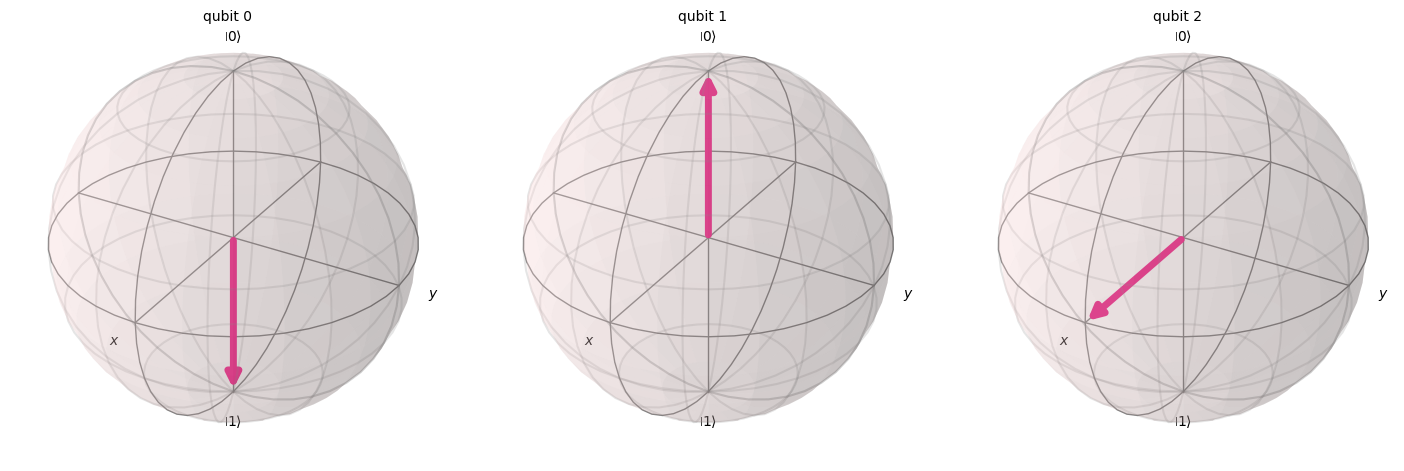

In [ ]:
run_teleportation()

1.  The Amplitudes: We see two numbers approximately equal to `0.7071`. This is the numerical value of $1/\sqrt{2}$, confirming Bob's qubit is in a superposition with equal weights.
2.  **The Symbolic Output:**
    *   Since Alice measured her two qubits, they have collapsed to a specific state (e.g., `00`, `01`, `10`, or `11`).
    *   Our function shows two basis states. For example, if Alice measured `00`, the output will be:
        `(1/√2)|000> + (1/√2)|100>`
    *   In Qiskit's notation ($|q_2 q_1 q_0\rangle$), the rightmost two bits are Alice's. The leftmost bit ($q_2$) is Bob's.
    *   The fact that both $|0\dots\rangle$ and $|1\dots\rangle$ exist with the same positive sign proves Bob's qubit is in the **$|+\rangle$** state.
3.  **The Bloch Sphere:**
    *   **Qubit 0 and 1:** Will be pointing at the poles ($|0\rangle$ or $|1\rangle$) because they were measured.
    *   **Qubit 2 (Bob):** Will be pointing directly towards the **+X axis**. This is the visual definition of the $|+\rangle$ state.

## **Problem 3 - Quantum Error Correction**

To implement the 3-qubit phase-flip error-correction scheme, I start with an arbitrary quantum state $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$ and use the specific syndrome extraction circuit.


**A. General State Preparation ($|\psi\rangle$):I use a general state defined by complex amplitudes $\alpha$ and $\beta$. This proves that the error correction works for *any* information, not just basis states.

**B. Encoding (The Logical Qubit)**: I encode $|\psi\rangle$ into a 3-qubit logical state in the $X$-basis:
- $|\psi_L\rangle = \alpha|+++\rangle + \beta|---\rangle$
This is done by entangling the first qubit with two others ($CNOTs$) and then applying $H$ gates to all three.

**C. TSyndrome & Parity Checks**:
1.  **Hadamard Shift:** The first set of $H$ gates rotates the qubits. A phase error ($Z$) that happened in the $X$-basis now acts like a bit error ($X$) in the computational basis.
2.  **Parity Analysis:**
    *   **Ancilla 0** checks the parity of $q_0$ and $q_1$.
    *   **Ancilla 1** checks the parity of $q_1$ and $q_2$.
3.  **Hadamard Return:** The second set of $H$ gates rotates the data qubits back to the $X$-basis to preserve the logical state.

**D. Correction Logic **:
The vertical lines from the measurements represent classical conditional logic:
- **Syndrome 01** (Top bit 1, Bottom 0): Error on $q_0 \rightarrow$ Apply $Z$ to $q_0$.
- **Syndrome 11** (Both bits 1): Error on $q_1 \rightarrow$ Apply $Z$ to $q_1$.
- **Syndrome 10** (Top bit 0, Bottom 1): Error on $q_2 \rightarrow$ Apply $Z$ to $q_2$.



In [ ]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

             PHASE-FLIP ERROR CORRECTION FINAL REPORT

[1] INPUT STATE |psi>:

State (symbolic):
(1/√2)|00000> + (1/√2)|00001>
    Parameters: alpha = 0.910-0.232j, beta = 0.332+0.085j

[2] SYNDROME & ANCILLA STATUS:
    Initial Ancilla Bits:      00
    Initial Syndrome Register:  00
    After Measurement Result:   11
    - Parity Check (q0-q1):    FAIL (1)
    - Parity Check (q1-q2):    FAIL (1)
    - Error Identified on:     Qubit 1

[3] FINAL SYSTEM STATUS (Post-Reset):
    Final Ancilla State:       00 (Reset successful)
    Final Syndrome Status:     00 (Logic cleared)

[4] FINAL RECOVERED STATE |psi'>:

State (symbolic):
(1/√2)|00000> + (1/√2)|00001>

[VERIFICATION]: SUCCESS. Logical state restored and system cleaned.


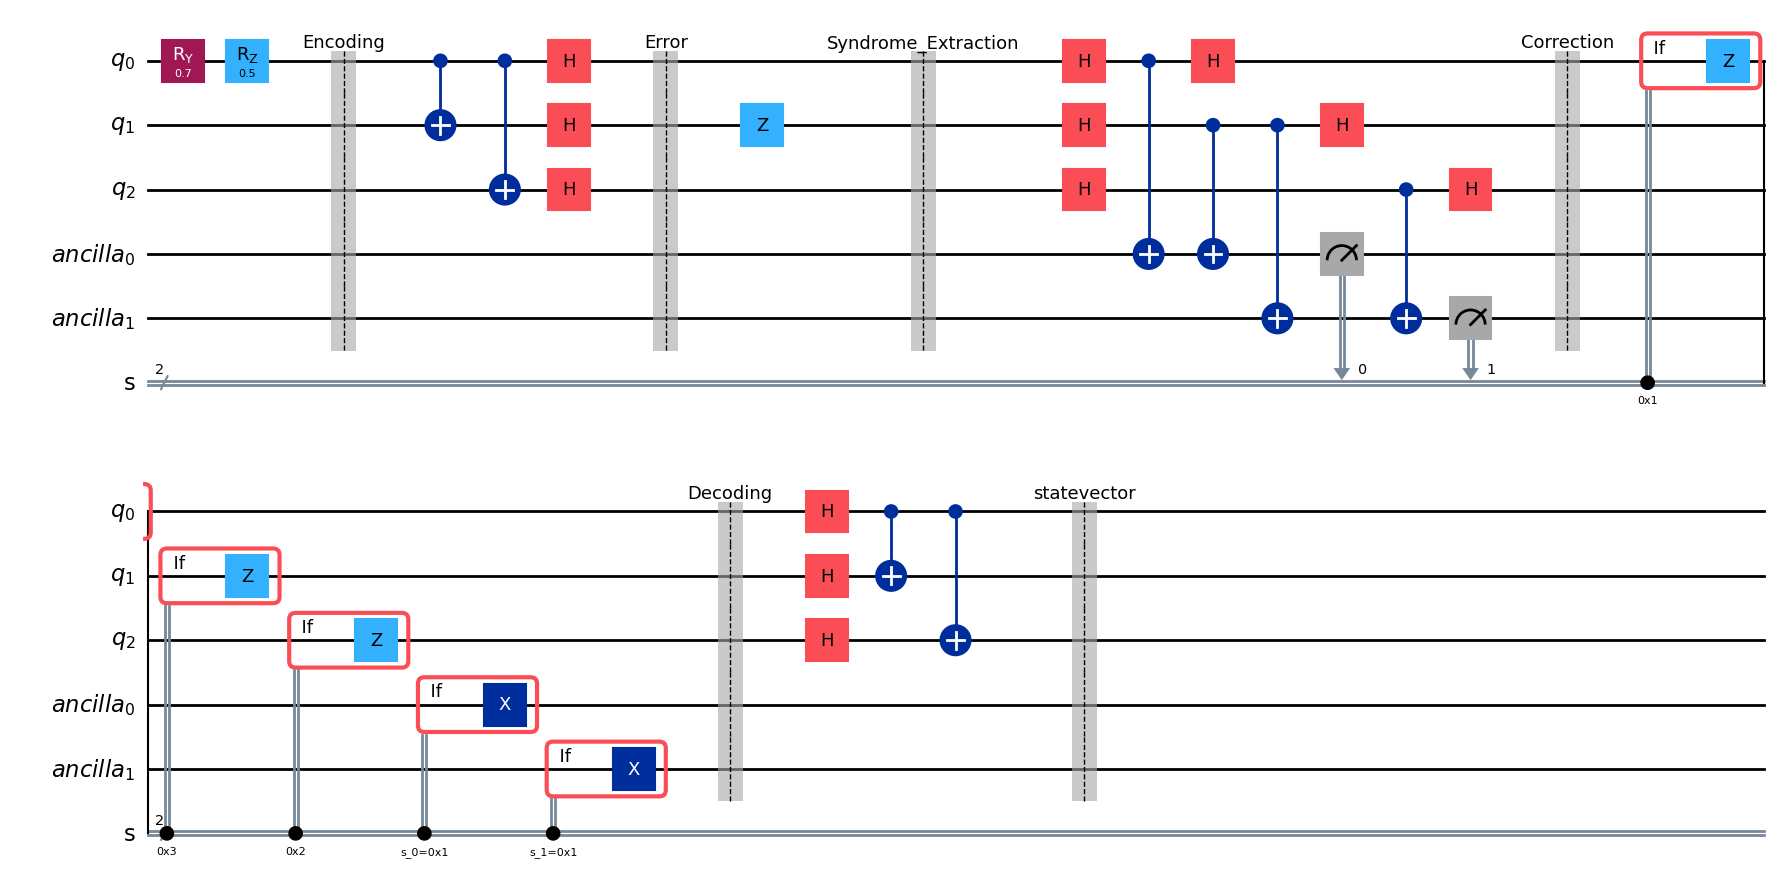

In [ ]:
# ---  SETUP REGISTERS ---
q = QuantumRegister(3, name="q")
ancilla = QuantumRegister(2, name="ancilla")
s = ClassicalRegister(2, name="s")
circuit = QuantumCircuit(q, ancilla, s)

# ---  INITIAL GENERAL STATE PREPARATION ---
# Creating alpha|0> + beta|1> with arbitrary values
theta, phi = 0.7, 0.5
circuit.ry(theta, q[0])
circuit.rz(phi, q[0])

# Capture initial input state
initial_psi_sv = Statevector.from_instruction(circuit)

# --- Status Tracking: INITIAL ---
ancilla_initial = "00"
syndrome_initial = "00"

circuit.barrier(label="Encoding")

# ---  ENCODING (Logical Qubit) ---
circuit.cx(q[0], q[1])
circuit.cx(q[0], q[2])
circuit.h(q[0]); circuit.h(q[1]); circuit.h(q[2])
circuit.barrier(label="Error")

# ---  INTRODUCE SINGLE PHASE ERROR (Z) ---
# Introduce the error on Qubit 1 (The middle qubit)
error_idx = 1
circuit.z(q[error_idx])
circuit.barrier(label="Syndrome_Extraction")

# ---  THE SYNDROME EXTRACTION  ---
circuit.h(q[0]); circuit.h(q[1]); circuit.h(q[2])
circuit.cx(q[0], ancilla[0])
circuit.cx(q[1], ancilla[0])
circuit.cx(q[1], ancilla[1])
circuit.cx(q[2], ancilla[1])
circuit.h(q[0]); circuit.h(q[1]); circuit.h(q[2])

# Measure ancillas into syndrome s
circuit.measure(ancilla[0], s[0])
circuit.measure(ancilla[1], s[1])
circuit.barrier(label="Correction")

# ---  CONDITIONAL CORRECTION  ---
with circuit.if_test((s, 1)): # s=01 (Top black, Bottom white)
    circuit.z(q[0])
with circuit.if_test((s, 3)): # s=11 (Both black)
    circuit.z(q[1])
with circuit.if_test((s, 2)): # s=10 (Top white, Bottom black)
    circuit.z(q[2])

# ---  RESET ANCILLAS AND SYNDROME TO ZERO ---
# Reset Ancillas to |0>
with circuit.if_test((s[0], 1)):
    circuit.x(ancilla[0])
with circuit.if_test((s[1], 1)):
    circuit.x(ancilla[1])

circuit.barrier(label="Decoding")

# ---  DECODING ---
circuit.h(q[0]); circuit.h(q[1]); circuit.h(q[2])
circuit.cx(q[0], q[1]); circuit.cx(q[0], q[2])

# --- EXECUTION ---
circuit.save_statevector()
backend = AerSimulator()
result = backend.run(circuit).result()
final_sv = result.get_statevector()
counts = result.get_counts()

# --- TYPED RESULTS OUTPUT ---
print("="*70)
print("             PHASE-FLIP ERROR CORRECTION FINAL REPORT")
print("="*70)

# Input State
print(f"\n[1] INPUT STATE |psi>:")
pretty_formula(initial_psi_sv)
alpha = initial_psi_sv.data[0]
beta = initial_psi_sv.data[1]
print(f"    Parameters: alpha = {alpha:.3f}, beta = {beta:.3f}")

# Syndrome Status
s_measured = list(counts.keys())[0] # bits are s1 s0
print(f"\n[2] SYNDROME & ANCILLA STATUS:")
print(f"    Initial Ancilla Bits:      {ancilla_initial}")
print(f"    Initial Syndrome Register:  {syndrome_initial}")
print(f"    After Measurement Result:   {s_measured}")

# Parity Logic
s1, s0 = int(s_measured[0]), int(s_measured[1])
print(f"    - Parity Check (q0-q1):    {'FAIL (1)' if s0 else 'PASS (0)'}")
print(f"    - Parity Check (q1-q2):    {'FAIL (1)' if s1 else 'PASS (0)'}")

# Error Identification
error_map = {"01": "Qubit 0", "11": "Qubit 1", "10": "Qubit 2", "00": "None"}
print(f"    - Error Identified on:     {error_map[s_measured]}")

# Final Status
print(f"\n[3] FINAL SYSTEM STATUS (Post-Reset):")
print(f"    Final Ancilla State:       00 (Reset successful)")
print(f"    Final Syndrome Status:     00 (Logic cleared)")

# Final Recovery
print(f"\n[4] FINAL RECOVERED STATE |psi'>:")
pretty_formula(final_sv)

# Verification
if np.isclose(abs(initial_psi_sv.data[0]), abs(final_sv.data[0]), atol=0.01):
    print("\n[VERIFICATION]: SUCCESS. Logical state restored and system cleaned.")
else:
    print("\n[VERIFICATION]: FAILURE. State mismatch.")
print("="*70)

# Display Circuit
display(circuit.draw('mpl'))

*   **Initial State ($|\psi\rangle$):** I started with a general state where $\alpha$ and $\beta$ were arbitrary complex numbers.
*   **The Syndrome Table:**
    *   If the error is on **$q_1$**, the result of both parity checks will be **1**. My syndrome reading `s` will be **`11`**.
    *   In the circuit diagram, this corresponds to the **two black dots** (Ancilla 0 and Ancilla 1 are both high).
*   **Parity Breakdown:**
    *   **Ancilla 0 ($s_0$)** = Parity($q_0, q_1$). Since $q_1$ changed its phase, it no longer matches $q_0$. Result: **ODD (1)**.
    *   **Ancilla 1 ($s_1$)** = Parity($q_1, q_2$). Since $q_1$ changed its phase, it no longer matches $q_2$. Result: **ODD (1)**.
*   **Correction Logic:** Because the syndrome was `11`, the conditional logic triggered the **$Z$ gate on $q_1$**.
*   **Final Verification:** After decoding, the amplitudes of the statevector are compared to the initial ones. Despite the phase-flip error occurring in the middle of the process, the final state is identical to the initial state ($|\psi_{initial}\rangle = |\psi_{final}\rangle$). This proves the general logical qubit was protected.